# Alternative Credit Scoring Model – Logistic Regression

This notebook implements Logistic Regression as a baseline model for predicting loan defaults 
in Cambodia’s unbanked population. The purpose is to evaluate whether alternative features 
(income, housing, employment stability) can substitute for traditional credit history.

In [1]:
# Import the necessary libraries for data handling, model training, evaluation, and visualization.
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

### Load Dataset

Load the engineered dataset (`featured_credit_risk_kh.csv`) which includes localized features 
such as Cambodian income ranges, land title mapping, debt-to-income ratio, stability score, and interest burden.


In [2]:
df = pd.read_csv("../data/processed/featured_credit_risk_kh.csv")
print(df.shape)
df.head()

(31650, 24)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_income_kh,loan_to_income_ratio,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,land_title_type_No Title,land_title_type_Soft Title,cb_person_default_on_file_Y,nbc_status_Loss,nbc_status_Normal (Standard),nbc_status_Special Mention,nbc_status_Substandard
0,21,9600,5.0,1000,11.14,0,0.10,2,2442.912215,0.104167,...,False,False,False,False,False,False,False,True,False,False
1,25,9600,1.0,5500,12.87,1,0.57,3,2442.912215,0.572917,...,True,False,False,False,False,False,False,False,True,False
2,23,65500,4.0,35000,15.23,1,0.53,2,2871.268072,0.534351,...,True,False,False,False,True,False,False,False,True,False
3,24,54400,8.0,35000,14.27,1,0.55,4,2786.209932,0.643382,...,True,False,False,False,True,True,False,False,True,False
4,21,9900,2.0,2500,7.14,1,0.25,2,2445.211083,0.252525,...,False,False,True,False,False,False,False,True,False,False


### Split Features & Target
- Separate the dataset into features (`X`) and target (`y`). 
- The target variable `loan_status` is binary: 0 = Safe, 1 = Default.
- We split the data into training (80%) and testing (20%) sets.

In [3]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Initialize Logistic Regression
- Initialize Logistic Regression with `liblinear` solver, suitable for small/medium datasets. 
- `max_iter=1000` ensures convergence, and `random_state=42` guarantees reproducibility.

In [4]:
log_reg = LogisticRegression(
    solver='liblinear',
    max_iter=1000,
    random_state=42
)

### Train the Model

- Train the Logistic Regression model on the training dataset.

In [5]:
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Make Predictions

- Generate predictions on the test dataset to evaluate model performance.

In [6]:
y_pred = log_reg.predict(X_test)

### Evaluate Model

- Evaluate the model using Accuracy, Precision, Recall, and F1-score. 
- Recall and F1-score are most important in financial risk contexts, since missing a default prediction can be costly. 
- The confusion matrix shows how well the model distinguishes safe vs default borrowers.

Accuracy: 0.8225908372827804
Precision: 0.711864406779661
Recall: 0.354181307097681
F1-score: 0.47301736274049744


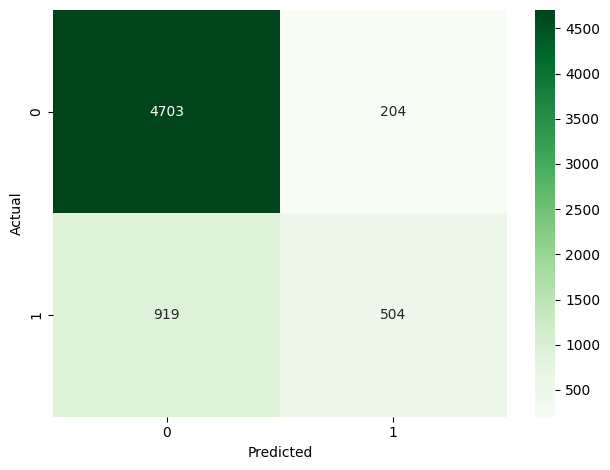

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../outputs/figures/logistic_regression/confusion_matrices_lr.png")
plt.show()

### Interpret Coefficients

- Logistic Regression coefficients indicate the influence of each feature on default risk. 
- Positive coefficients increase the likelihood of default, while negative coefficients reduce it. 
- This helps identify which features are most important for credit scoring.

In [9]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coefficients

,Feature,Coefficient
4,loan_int_rate,0.298465
17,land_title_type_Soft Title,0.139306
22,nbc_status_Substandard,0.110678
13,loan_intent_MEDICAL,0.034873
18,cb_person_default_on_file_Y,0.034564
12,loan_intent_HOMEIMPROVEMENT,0.030008
8,loan_to_income_ratio,0.021269
5,loan_percent_income,0.020050
6,cb_person_cred_hist_length,0.015127
19,nbc_status_Loss,0.011603


### Save the result

- Save the evaluation metrics into `results_summary.txt` and export the trained model 
as `logistic_regression.pkl` for reuse in production or comparison with other models.


In [10]:
with open("../outputs/reports/results_summary.txt", "w") as f:
    f.write(f"Accuracy: {accuracy_score(y_test, y_pred)}\n")
    f.write(f"Precision: {precision_score(y_test, y_pred)}\n")
    f.write(f"Recall: {recall_score(y_test, y_pred)}\n")
    f.write(f"F1-score: {f1_score(y_test, y_pred)}\n")

joblib.dump(log_reg, "../outputs/models/logistic_regression.pkl")

['../outputs/models/logistic_regression.pkl']